In [ ]:
!pip -q install ultralytics
import os, glob, yaml, shutil
from ultralytics import YOLO
from google.colab import files

subida = files.upload()          # elige merged.zip
!unzip -qo merged.zip -d /content/

DATA_YAML = "/content/merged/data.yaml"
cfg = yaml.safe_load(open(DATA_YAML))
FINAL = cfg["names"]
print(FINAL, "->", cfg["nc"], "clases")

for split in ["train","valid","test"]:
    n = len(glob.glob(f"/content/merged/{split}/images/*.jpg"))
    print(f"{split:<6} {n:>4}")

Saving merged.zip to merged (2).zip
['asa_5520', 'catalyst_2960', 'catalyst_3750g', 'catalyst_8200', 'catalyst_9200', 'cisco_2800', 'grandstream_ucm', 'nexxt_switch', 'telefono_yealink'] -> 9 clases
train   144
valid    41
test     21


In [ ]:
import glob, shutil, os
from ultralytics import YOLO

best = YOLO("runs/detect/redes_uteq_v2/weights/best.pt")
ruta = str(best.export(format="tflite", imgsz=640))
if not ruta.endswith(".tflite"):
    ruta = sorted(glob.glob(f"{ruta}/*float32.tflite"))[0]
shutil.copy(ruta, "redes_uteq.tflite")
print(f"{os.path.getsize('redes_uteq.tflite')/1e6:.1f} MB")

from google.colab import files
files.download("redes_uteq.tflite")

WARNING ⚠️ format='tflite' is deprecated as of 8.4.83 and has been replaced by the unified Google LiteRT format. Exporting format='litert' instead. See https://docs.ultralytics.com/integrations/litert
Ultralytics 8.4.146 🚀 Python-3.13.15 torch-2.11.0+cu128 CPU (Intel Xeon CPU @ 2.00GHz)
💡 ProTip: Export to OpenVINO format for best performance on Intel hardware. Learn more at https://docs.ultralytics.com/integrations/openvino
YOLO11n summary (fused): 100 layers, 2,583,907 parameters, 0 gradients, 6.4 GFLOPs

PyTorch: starting from 'runs/detect/redes_uteq_v2/weights/best.pt' with input shape (1, 3, 640, 640) BCHW and output shape(s) (1, 13, 8400) (5.2 MB)
requirements: Ultralytics requirements ['litert-torch>=0.9.0', 'ai-edge-litert>=2.1.4'] not found, attempting AutoUpdate...
Using Python 3.13.15 environment at: /usr
Resolved 86 packages in 689ms
Prepared 15 packages in 1.88s
Uninstalled 3 packages in 31ms
Installed 15 packages in 45ms
 + ai-edge-litert==2.2.0
 + ai-edge-quantizer==0.9.

/usr/local/lib/python3.13/dist-packages/torchao/quantization/quant_api.py:1558: SyntaxWarning: invalid escape sequence '\.'
  * regex for parameter names, must start with `re:`, e.g. `re:language\.layers\..+\.q_proj.weight`.



LiteRT: starting export with litert_torch 0.9.4...


(00:00) [START] LiteRT-Torch Convert

(00:00) [START] LiteRT-Torch Convert > Torch Export: serving_default

...

(00:00) [START] Write Model to runs/detect/redes_uteq_v2/weights/best.tflite

(00:00) [ DONE] Write Model to runs/detect/redes_uteq_v2/weights/best.tflite (+00:00)

LiteRT: export success ✅ 26.9s, saved as 'runs/detect/redes_uteq_v2/weights/best.tflite' (10.1 MB)

Export complete (27.5s)
Results saved to /content/runs/detect/redes_uteq_v2/weights/best.tflite
Predict:         yolo predict task=detect model=runs/detect/redes_uteq_v2/weights/best.tflite imgsz=640 
Validate:        yolo val task=detect model=runs/detect/redes_uteq_v2/weights/best.tflite imgsz=640 data=/content/merged/data.yaml  
Visualize:       https://netron.app
10.6 MB


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
YOLO("yolo11n.pt").train(
    data=DATA_YAML, epochs=200, patience=50, imgsz=640, batch=16,
    name="redes_uteq_v2", seed=42,
    hsv_h=0.015, hsv_s=0.5, hsv_v=0.4,
    degrees=8, translate=0.1, scale=0.4,
    fliplr=0.0, flipud=0.0, mosaic=1.0, close_mosaic=15)

Ultralytics 8.4.146 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=None, classes=None, close_mosaic=15, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/merged/data.yaml, degrees=8, deterministic=True, device=, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=200, erasing=0.4, exist_ok=False, fliplr=0.0, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.5, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=redes_uteq_v2-2, nbs=64, nms=None, opset=None, optim

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0, 1, 2, 3, 4, 5, 6, 7, 8])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7ab5be9c91d0>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.0470

# Detección de equipos — Laboratorio de Redes UTEQ
### Modelo v1 · dataset fusionado (v1 + v2)

Este cuaderno **une los dos datasets** del proyecto de Roboflow en uno solo antes de entrenar.

| | Fotos originales | Clases | Notas |
|---|---|---|---|
| **version(1)** | ~60 | 6 | agosto · exportada con 3 copias augmentadas por foto |
| **version(2)** | 146 | 9 | septiembre · sin augmentación, split 100/0/0 |

Tres cosas que hace la fusión y que conviene entender antes de correrla:

1. **Descarta las copias augmentadas de la v1.** Esa exportación trae cada foto tres veces con distinto hash. Si se dejan, el modelo ve la misma imagen en train y en valid y el mAP sale inflado.
2. **Remapea las clases por nombre, no por índice.** La v1 tiene 6 clases y la v2 tiene 9, así que el índice `3` no significa lo mismo en las dos. Se construye la unión ordenada y se traduce cada etiqueta.
3. **Rehace el split 70/20/10** sobre el conjunto ya unido, con semilla fija para que sea reproducible.

---

## Antes de correr

**Entorno de ejecución → Cambiar tipo de entorno de ejecución → GPU T4 → Guardar.**

Sin GPU el entrenamiento pasa de ~25 minutos a varias horas.

---
## 1 · Entorno

In [ ]:
!pip -q install ultralytics roboflow

import glob, os, random, shutil, yaml
from collections import Counter
from pathlib import Path

import torch, ultralytics
from ultralytics import YOLO

print("ultralytics", ultralytics.__version__)
print("GPU disponible:", torch.cuda.is_available())
if torch.cuda.is_available():
    print(torch.cuda.get_device_name(0))
else:
    print("Sin GPU: cambia el entorno de ejecucion a T4 antes de seguir.")

ultralytics 8.4.144
GPU disponible: True
Tesla T4


---
## 2 · Descargar las dos versiones

La API key va aquí. Si esta key ya circuló en un chat o en un notebook compartido, regenérala en Roboflow → Settings → API Keys antes de seguir.

In [ ]:
API_KEY = "ZUorxgrFr6e0dV1F5c81"

from roboflow import Roboflow

rf   = Roboflow(api_key=API_KEY)
proj = rf.workspace("amendozab5-uteq-edu-ec").project("equipos-redes-uteq-2026")

ds_v1 = proj.version(1).download("yolov8", location="/content/ds_v1")
ds_v2 = proj.version(2).download("yolov8", location="/content/ds_v2")

# Nombres viejos o mal escritos -> nombre correcto.
# catalyst_8300 no existe: el equipo real del rack FYTEC es un catalyst_8200.
# La v1 se etiquetó con el nombre equivocado y se corrigió en la v2.
ALIAS = {
    "catalyst_8300": "catalyst_8200",
}

def clases_de(loc):
    crudas = yaml.safe_load(open(f"{loc}/data.yaml"))["names"]
    return [ALIAS.get(n, n) for n in crudas]

nombres_v1 = clases_de(ds_v1.location)
nombres_v2 = clases_de(ds_v2.location)
FINAL      = sorted(set(nombres_v1) | set(nombres_v2))

print("v1   :", nombres_v1)
print("v2   :", nombres_v2)
print("union:", FINAL, f"-> {len(FINAL)} clases")

# aviso por si quedan nombres sospechosamente parecidos entre sí
import difflib
for i, a in enumerate(FINAL):
    for b in FINAL[i+1:]:
        if difflib.SequenceMatcher(None, a, b).ratio() > 0.85:
            print(f"\n  OJO: '{a}' y '{b}' se parecen mucho. Typo? Agregalos a ALIAS si son el mismo equipo.")

loading Roboflow workspace...
loading Roboflow project...
v1   : ['asa_5520', 'catalyst_2960', 'catalyst_3750g', 'catalyst_8200', 'catalyst_9200', 'cisco_2800']
v2   : ['catalyst_2960', 'catalyst_8200', 'catalyst_9200', 'cisco_2800', 'grandstream_ucm', 'nexxt_switch', 'telefono_yealink']
union: ['asa_5520', 'catalyst_2960', 'catalyst_3750g', 'catalyst_8200', 'catalyst_9200', 'cisco_2800', 'grandstream_ucm', 'nexxt_switch', 'telefono_yealink'] -> 9 clases

  OJO: 'catalyst_8200' y 'catalyst_9200' se parecen mucho. Typo? Agregalos a ALIAS si son el mismo equipo.


### Revisa la unión antes de seguir

Mira la lista `union` que acaba de imprimirse. Si aparecen dos nombres casi iguales —`catalyst_3750g` y `catalyst_3750G`, por ejemplo— es un typo al etiquetar, no dos equipos distintos.

Un typo aquí parte los datos de esa clase en dos mitades y el modelo aprende peor las dos. **Si ves uno, arréglalo en Roboflow (Classes & Tags → renombrar), genera de nuevo la versión y vuelve a correr esta celda.**

---
## 3 · Fusionar

Aquí es donde se descartan las copias augmentadas, se traducen los índices de clase y se rehace el reparto.

In [ ]:
OUT = Path("/content/merged")
if OUT.exists():
    shutil.rmtree(OUT)          # empezar limpio si vuelves a correr la celda
for s in ["train", "valid", "test"]:
    (OUT / s / "images").mkdir(parents=True, exist_ok=True)
    (OUT / s / "labels").mkdir(parents=True, exist_ok=True)

todas = []

def recolectar(loc, nombres, etiqueta):
    """Junta las fotos ORIGINALES de un dataset, sin las copias augmentadas.

    Roboflow nombra las augmentadas <foto>_jpg.rf.<hash>.jpg: mismo prefijo,
    distinto hash. Nos quedamos con la primera de cada prefijo.
    """
    remap  = {i: FINAL.index(n) for i, n in enumerate(nombres)}
    vistos = set()
    antes  = len(todas)
    for split in ["train", "valid", "test"]:
        carpeta = Path(loc, split, "images")
        if not carpeta.is_dir():
            continue
        for img in sorted(carpeta.glob("*.jpg")):
            prefijo = img.name.split("_jpg.rf.")[0]
            if prefijo in vistos:
                continue
            vistos.add(prefijo)
            lbl = Path(loc, split, "labels", img.stem + ".txt")
            if lbl.exists():
                todas.append((img, lbl, f"{etiqueta}_{img.name}", remap))
    print(f"{etiqueta}: {len(todas) - antes} fotos originales")

recolectar(ds_v1.location, nombres_v1, "v1")
recolectar(ds_v2.location, nombres_v2, "v2")

random.seed(42)                 # reparto reproducible entre corridas
random.shuffle(todas)

n = len(todas)
cortes = [("train", 0, int(n * .7)),
          ("valid", int(n * .7), int(n * .9)),
          ("test",  int(n * .9), n)]

conteo = Counter()
for split, a, b in cortes:
    for img, lbl, destino, remap in todas[a:b]:
        lineas = []
        for linea in lbl.read_text().splitlines():
            if not linea.strip():
                continue
            partes = linea.split()
            nuevo  = remap[int(partes[0])]
            partes[0] = str(nuevo)
            conteo[FINAL[nuevo]] += 1
            lineas.append(" ".join(partes))
        shutil.copy(img, OUT / split / "images" / destino)
        (OUT / split / "labels" / (Path(destino).stem + ".txt")).write_text("\n".join(lineas))
    print(f"{split:<6} {b - a:>4} imagenes")

yaml.safe_dump({"train": "../train/images",
                "val":   "../valid/images",
                "test":  "../test/images",
                "nc":    len(FINAL),
                "names": FINAL},
               open(OUT / "data.yaml", "w"), sort_keys=False, allow_unicode=True)

DATA_YAML = str(OUT / "data.yaml")
print("\nTOTAL:", n, "imagenes reales")
print(DATA_YAML)

v1: 60 fotos originales
v2: 146 fotos originales
train   144 imagenes
valid    41 imagenes
test     21 imagenes

TOTAL: 206 imagenes reales
/content/merged/data.yaml


### Cajas por clase

Este conteo es material directo para la diapositiva 3 y es tu control de calidad: una clase con menos de ~40 cajas no la va a aprender bien el modelo, y conviene decirlo tú antes de que lo pregunten.

In [ ]:
ancho = max(len(c) for c in FINAL) + 2
total_cajas = sum(conteo.values())

print(f"{'clase':<{ancho}}{'cajas':>7}{'%':>8}")
print("-" * (ancho + 15))
for clase, cajas in conteo.most_common():
    pct  = 100 * cajas / total_cajas
    aviso = "   <-- pocas" if cajas < 40 else ""
    print(f"{clase:<{ancho}}{cajas:>7}{pct:>7.1f}%{aviso}")
print("-" * (ancho + 15))
print(f"{'TOTAL':<{ancho}}{total_cajas:>7}")

faltantes = [c for c in FINAL if conteo[c] == 0]
if faltantes:
    print("\nSIN NINGUNA CAJA:", faltantes)

clase               cajas       %
---------------------------------
cisco_2800            299   28.3%
catalyst_8200         187   17.7%
catalyst_9200         177   16.7%
catalyst_2960         156   14.7%
nexxt_switch          105    9.9%
telefono_yealink       41    3.9%
grandstream_ucm        32    3.0%   <-- pocas
catalyst_3750g         31    2.9%   <-- pocas
asa_5520               30    2.8%   <-- pocas
---------------------------------
TOTAL                1058


---
## 4 · Entrenar

Se entrenan **dos tamaños de modelo** para poder compararlos.

La letra final del nombre es el tamaño: `n` = nano (~2.6 M parámetros), `s` = small (~9 M), `m` = medium (~20 M). Misma arquitectura, distinta cantidad de filtros por capa.

**Por qué comparar en vez de elegir uno**: distinguir un `catalyst_9200` de un `catalyst_8300` es un problema de detalle fino —dos cajas blancas que se diferencian por la disposición de los puertos— y ahí un modelo más grande suele ganar. Pero esto termina en una app Android, donde la nano pesa ~6 MB y la medium ~40 MB y corre bastante más lento. La decisión correcta depende de cuánto mAP compra ese peso extra, y eso se mide, no se supone.

Sobre los parámetros de aumento: `fliplr=0.0` porque voltear la imagen le enseñaría al modelo lo contrario de lo que distingue un switch de un router en estas fotos (la posición de puertos y logo). `mosaic=1.0` mezcla imágenes durante el entrenamiento y ayuda mucho con pocos datos; `close_mosaic=15` lo apaga en las últimas épocas para afinar.

Cada entrenamiento tarda entre 15 y 30 minutos en la T4. Aprovecha para armar las diapositivas.

In [ ]:
TAMANOS = ["n", "m"]          # deja solo ["s"] si vas corto de tiempo

for tam in TAMANOS:
    print(f"\n{'='*60}\n  yolo11{tam}\n{'='*60}")
    YOLO(f"yolo11{tam}.pt").train(
        data=DATA_YAML,
        epochs=200,           # mas datos que el v0 -> mas margen
        patience=50,          # el v0 se corto en la epoca 108 con patience=30
        imgsz=640,
        batch=16 if tam == "n" else 8,   # la medium consume mas VRAM
        name=f"redes_uteq_v1_{tam}",
        seed=42,

        hsv_h=0.015, hsv_s=0.5, hsv_v=0.4,
        degrees=8, translate=0.1, scale=0.4,
        fliplr=0.0, flipud=0.0,
        mosaic=1.0, close_mosaic=15,
    )


  yolo11n
New https://pypi.org/project/ultralytics/8.4.145 available 😃 Update with 'pip install -U ultralytics'
Ultralytics 8.4.144 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=None, classes=None, close_mosaic=15, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/merged/data.yaml, degrees=8, deterministic=True, device=, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=200, erasing=0.4, exist_ok=False, fliplr=0.0, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.5, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=y

Si la medium te da `CUDA out of memory`, baja su `batch` a 4 y vuelve a correr la celda.

---
## 5 · Evaluar sobre el conjunto de prueba

Estas son imágenes que el modelo **nunca vio**. Es el número honesto, el que va en la presentación.

In [ ]:
resumen = {}

for tam in TAMANOS:
    ruta_best = f"runs/detect/redes_uteq_v1_{tam}/weights/best.pt"
    if not os.path.exists(ruta_best):
        continue
    modelo = YOLO(ruta_best)
    m = modelo.val(split="test", name=f"eval_{tam}")
    peso_mb = os.path.getsize(ruta_best) / 1e6
    resumen[tam] = (m.box.map50, m.box.map, peso_mb, modelo, m)

print(f"\n{'modelo':<10}{'mAP50':>9}{'mAP50-95':>11}{'peso .pt':>11}")
print("-" * 41)
for tam, (m50, m5095, peso, _, _) in resumen.items():
    print(f"yolo11{tam:<4}{m50:>9.3f}{m5095:>11.3f}{peso:>9.1f} MB")

Ultralytics 8.4.144 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLO11n summary (fused): 100 layers, 2,583,907 parameters, 0 gradients, 6.4 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 194.1±251.6 MB/s, size: 50.5 KB)
val: Scanning /content/merged/test/labels... 21 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 21/21 746.0it/s 0.0s
val: New cache created: /content/merged/test/labels.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 2/2 1.9it/s 1.0s
                   all         21        102      0.971      0.989      0.994      0.747
              asa_5520          6          6      0.961          1      0.995      0.856
         catalyst_2960         10         15      0.932      0.908      0.987      0.739
        catalyst_3750g          6          6       0.97          1      0.995      0.833
         catalyst_8200          7         15      0.998          1      0.995      0.755
 

### Desglose por clase

El promedio esconde el detalle. Si una clase tiene el 30 % de las cajas y le va perfecto, sube el promedio sin que el modelo sea bueno en el resto — por eso esta tabla importa más que el número global.

In [ ]:
for tam, (_, _, _, _, m) in resumen.items():
    print(f"\n=== yolo11{tam} ===")
    print(f"{'clase':<24}{'precision':>11}{'recall':>9}{'mAP50':>9}")
    print("-" * 53)
    for i, c in enumerate(m.box.ap_class_index):
        print(f"{FINAL[c]:<24}{m.box.p[i]:>11.3f}{m.box.r[i]:>9.3f}{m.box.ap50[i]:>9.3f}")


=== yolo11n ===
clase                     precision   recall    mAP50
-----------------------------------------------------
asa_5520                      0.961    1.000    0.995
catalyst_2960                 0.932    0.908    0.987
catalyst_3750g                0.970    1.000    0.995
catalyst_8200                 0.998    1.000    0.995
catalyst_9200                 0.988    1.000    0.995
cisco_2800                    0.999    1.000    0.995
nexxt_switch                  0.980    1.000    0.995
telefono_yealink              0.941    1.000    0.995

=== yolo11m ===
clase                     precision   recall    mAP50
-----------------------------------------------------
asa_5520                      0.852    0.963    0.924
catalyst_2960                 0.965    1.000    0.995
catalyst_3750g                0.843    1.000    0.995
catalyst_8200                 1.000    0.983    0.995
catalyst_9200                 1.000    0.957    0.995
cisco_2800                    0.986    1.000    

### Elige el modelo que vas a presentar

Por defecto se queda con el de mejor mAP50-95. Cámbialo a mano si prefieres priorizar el tamaño para la app.

In [ ]:
MEJOR = max(resumen, key=lambda t: resumen[t][1])
best  = resumen[MEJOR][3]
R     = f"runs/detect/redes_uteq_v1_{MEJOR}"
print("Modelo elegido:", f"yolo11{MEJOR}", "->", R)

Modelo elegido: yolo11n -> runs/detect/redes_uteq_v1_n


### Gráficas para las diapositivas


=== Distribucion de clases y cajas ===


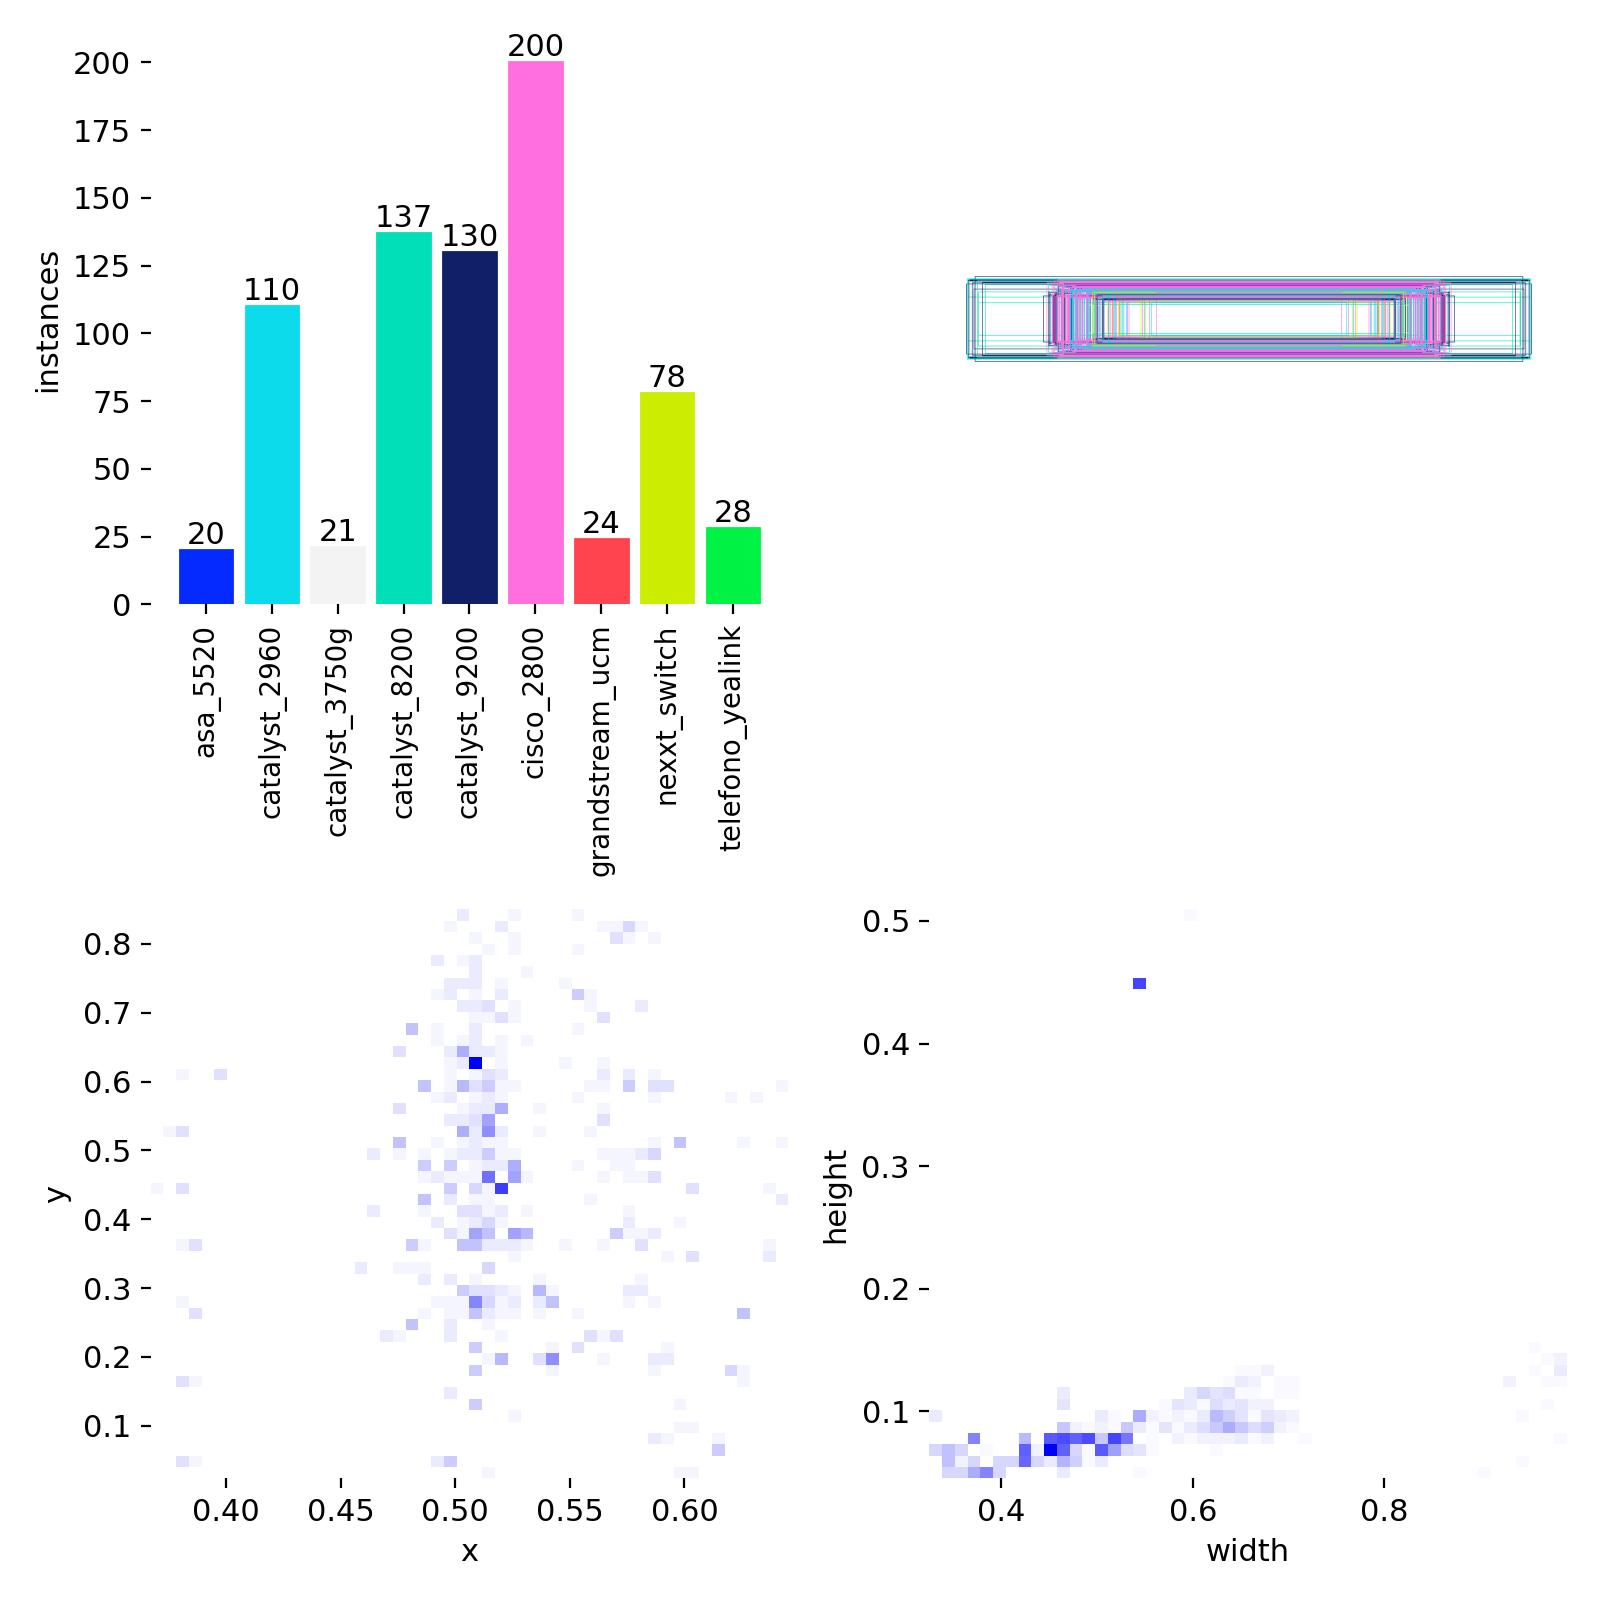


=== Curvas de entrenamiento ===


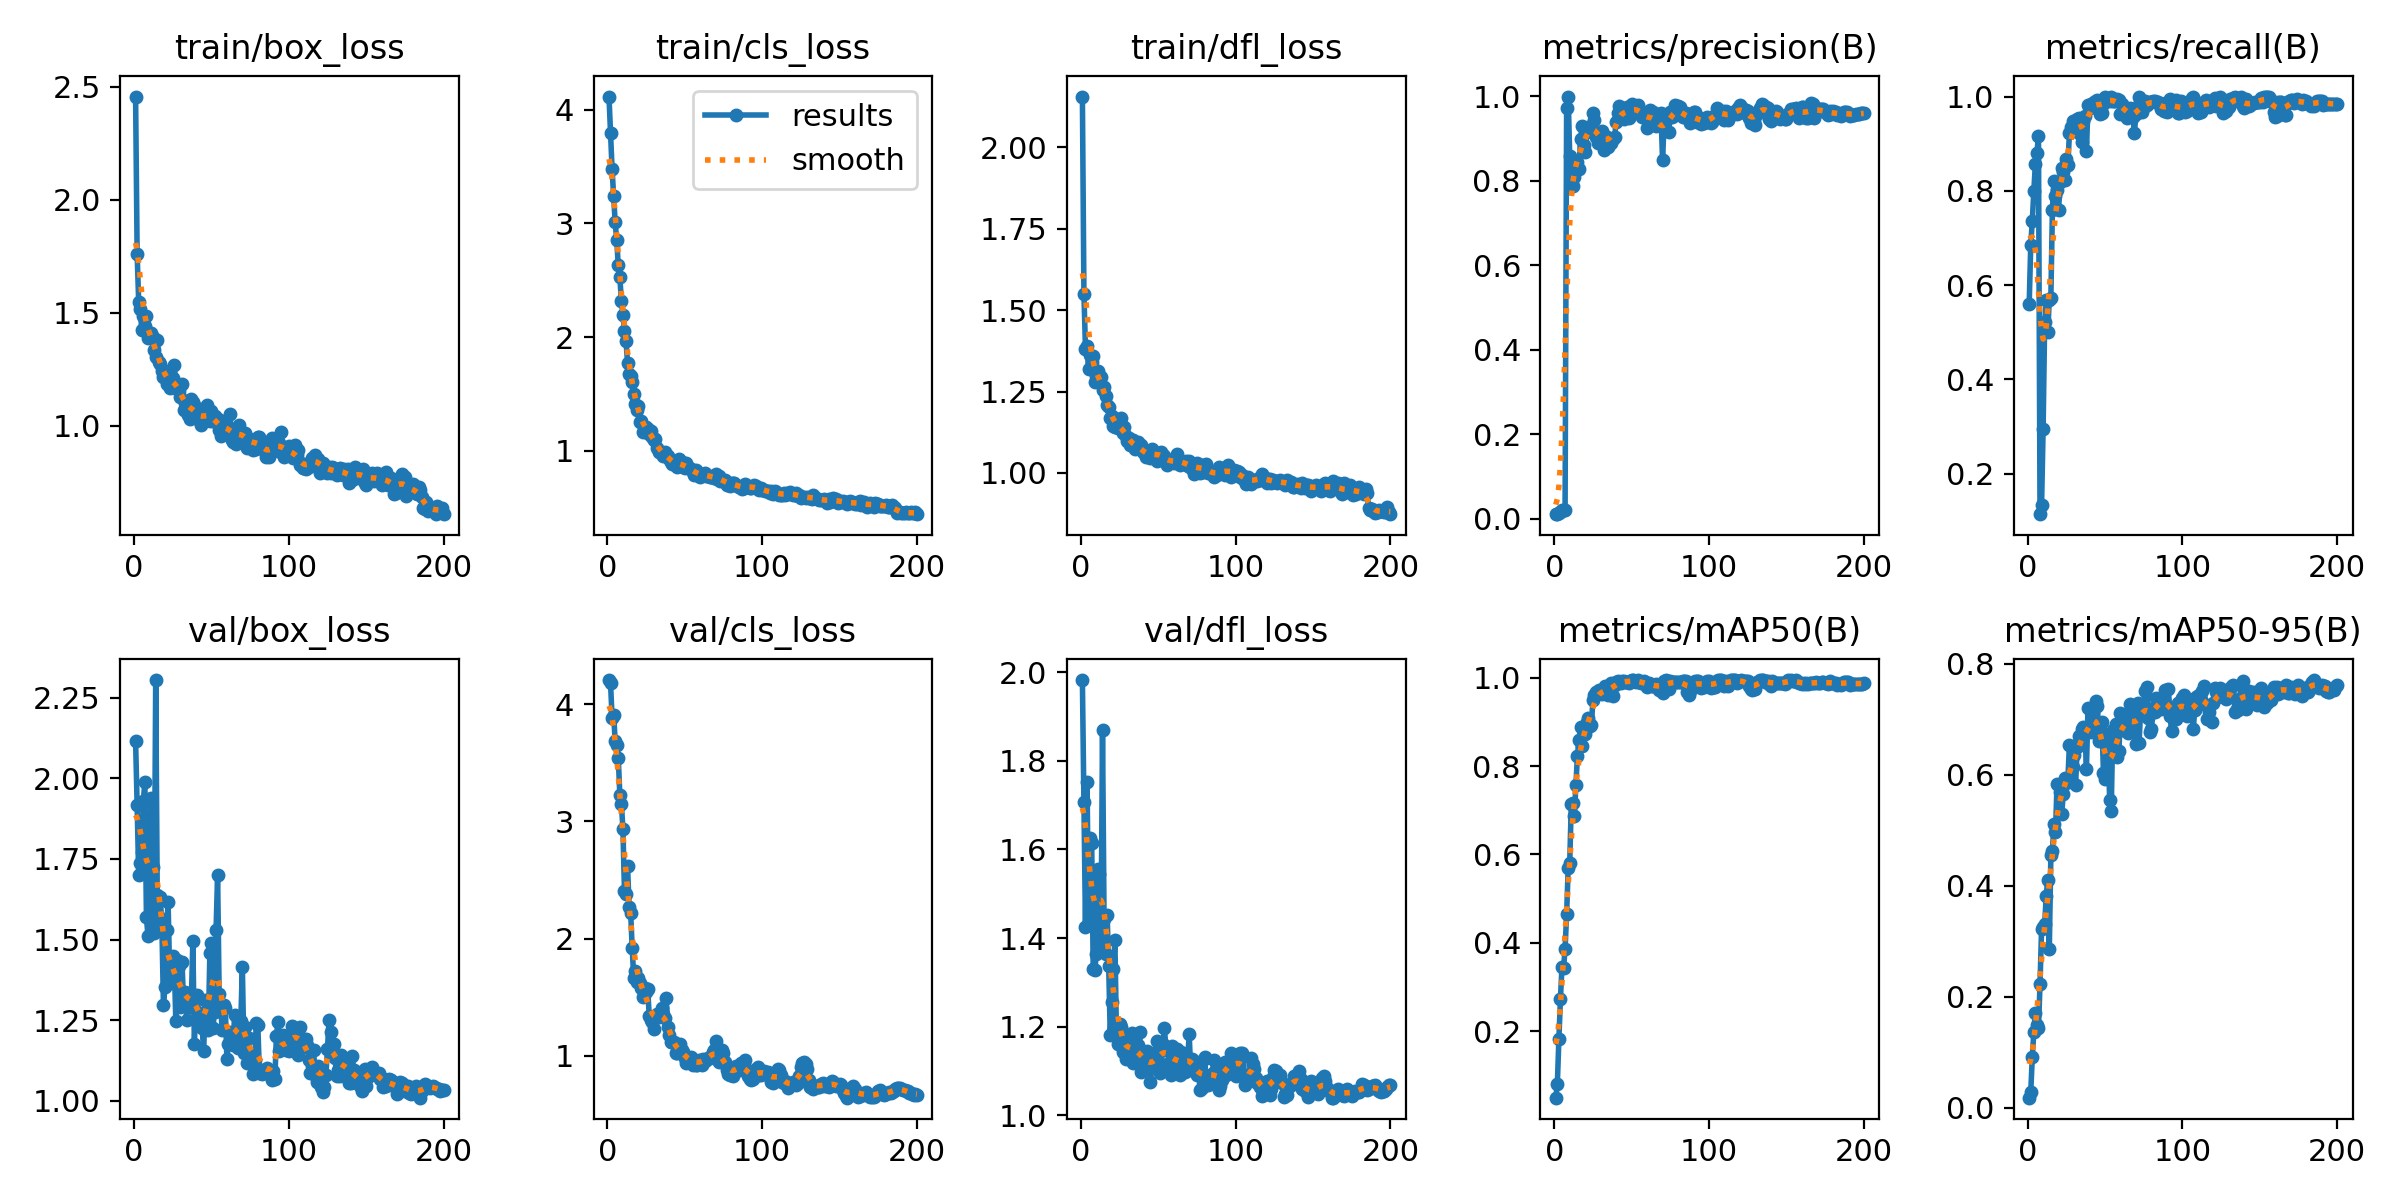


=== Matriz de confusion ===


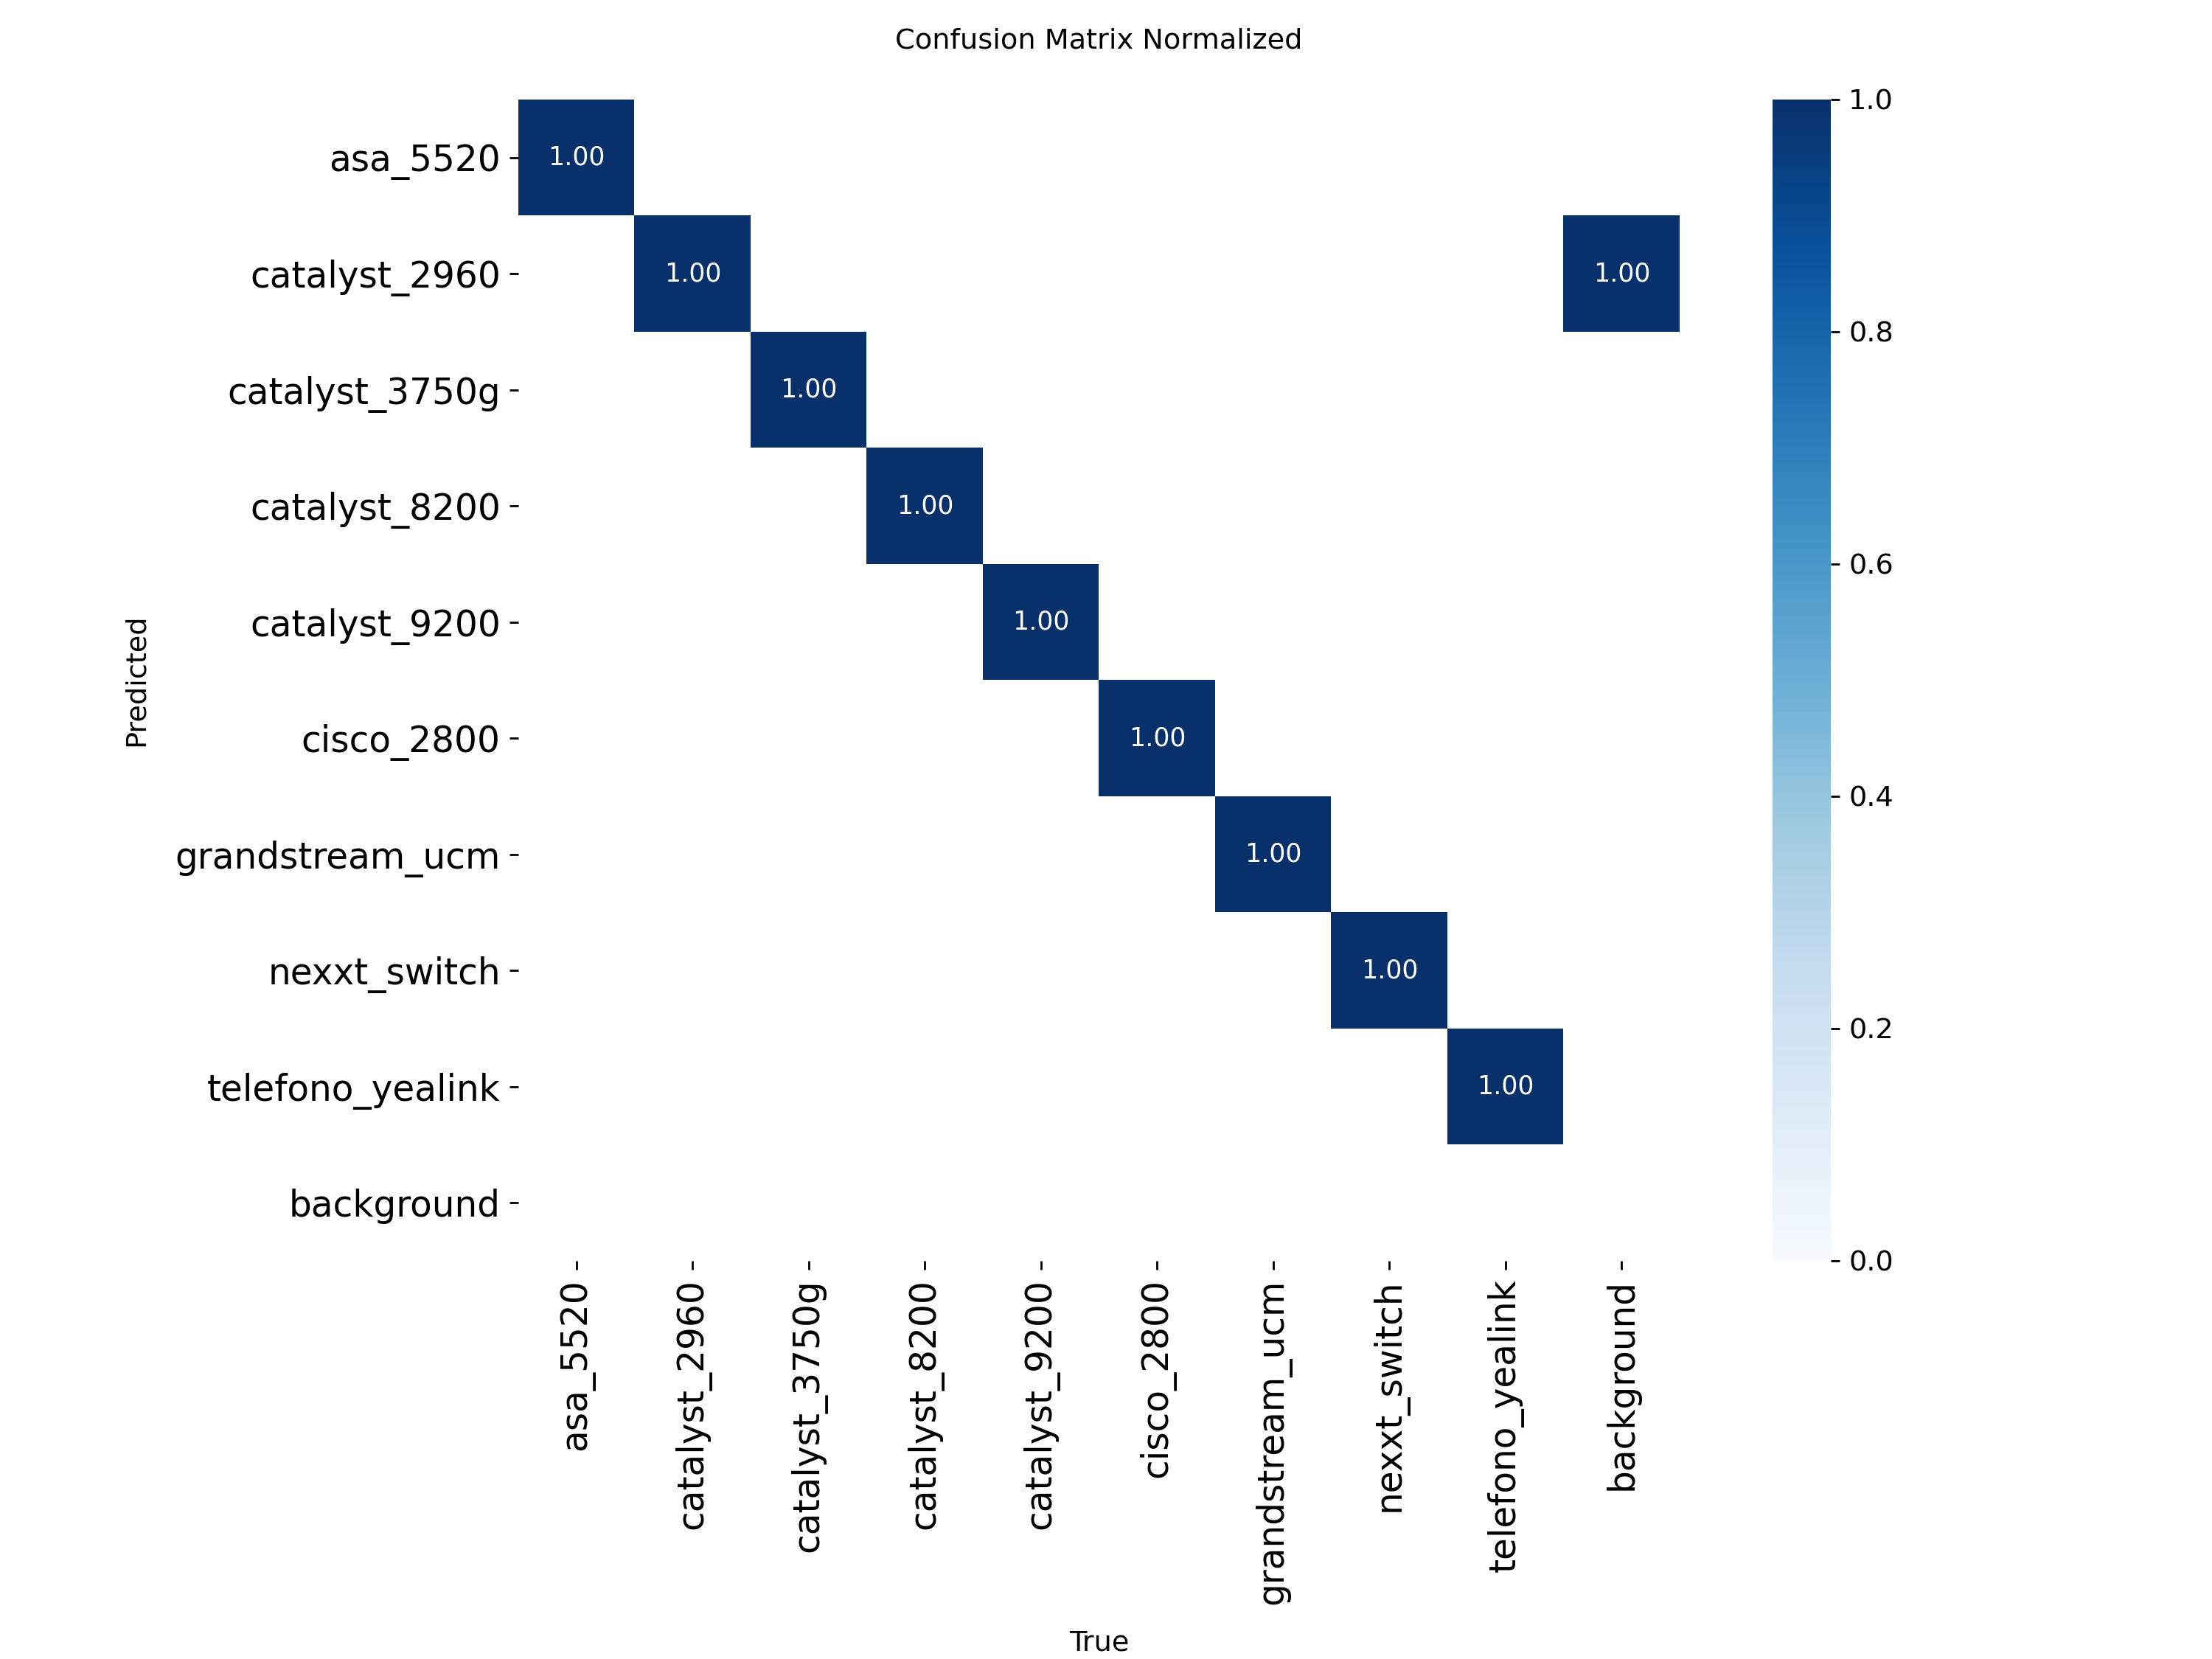


=== Ground truth (lo que etiquetaste) ===


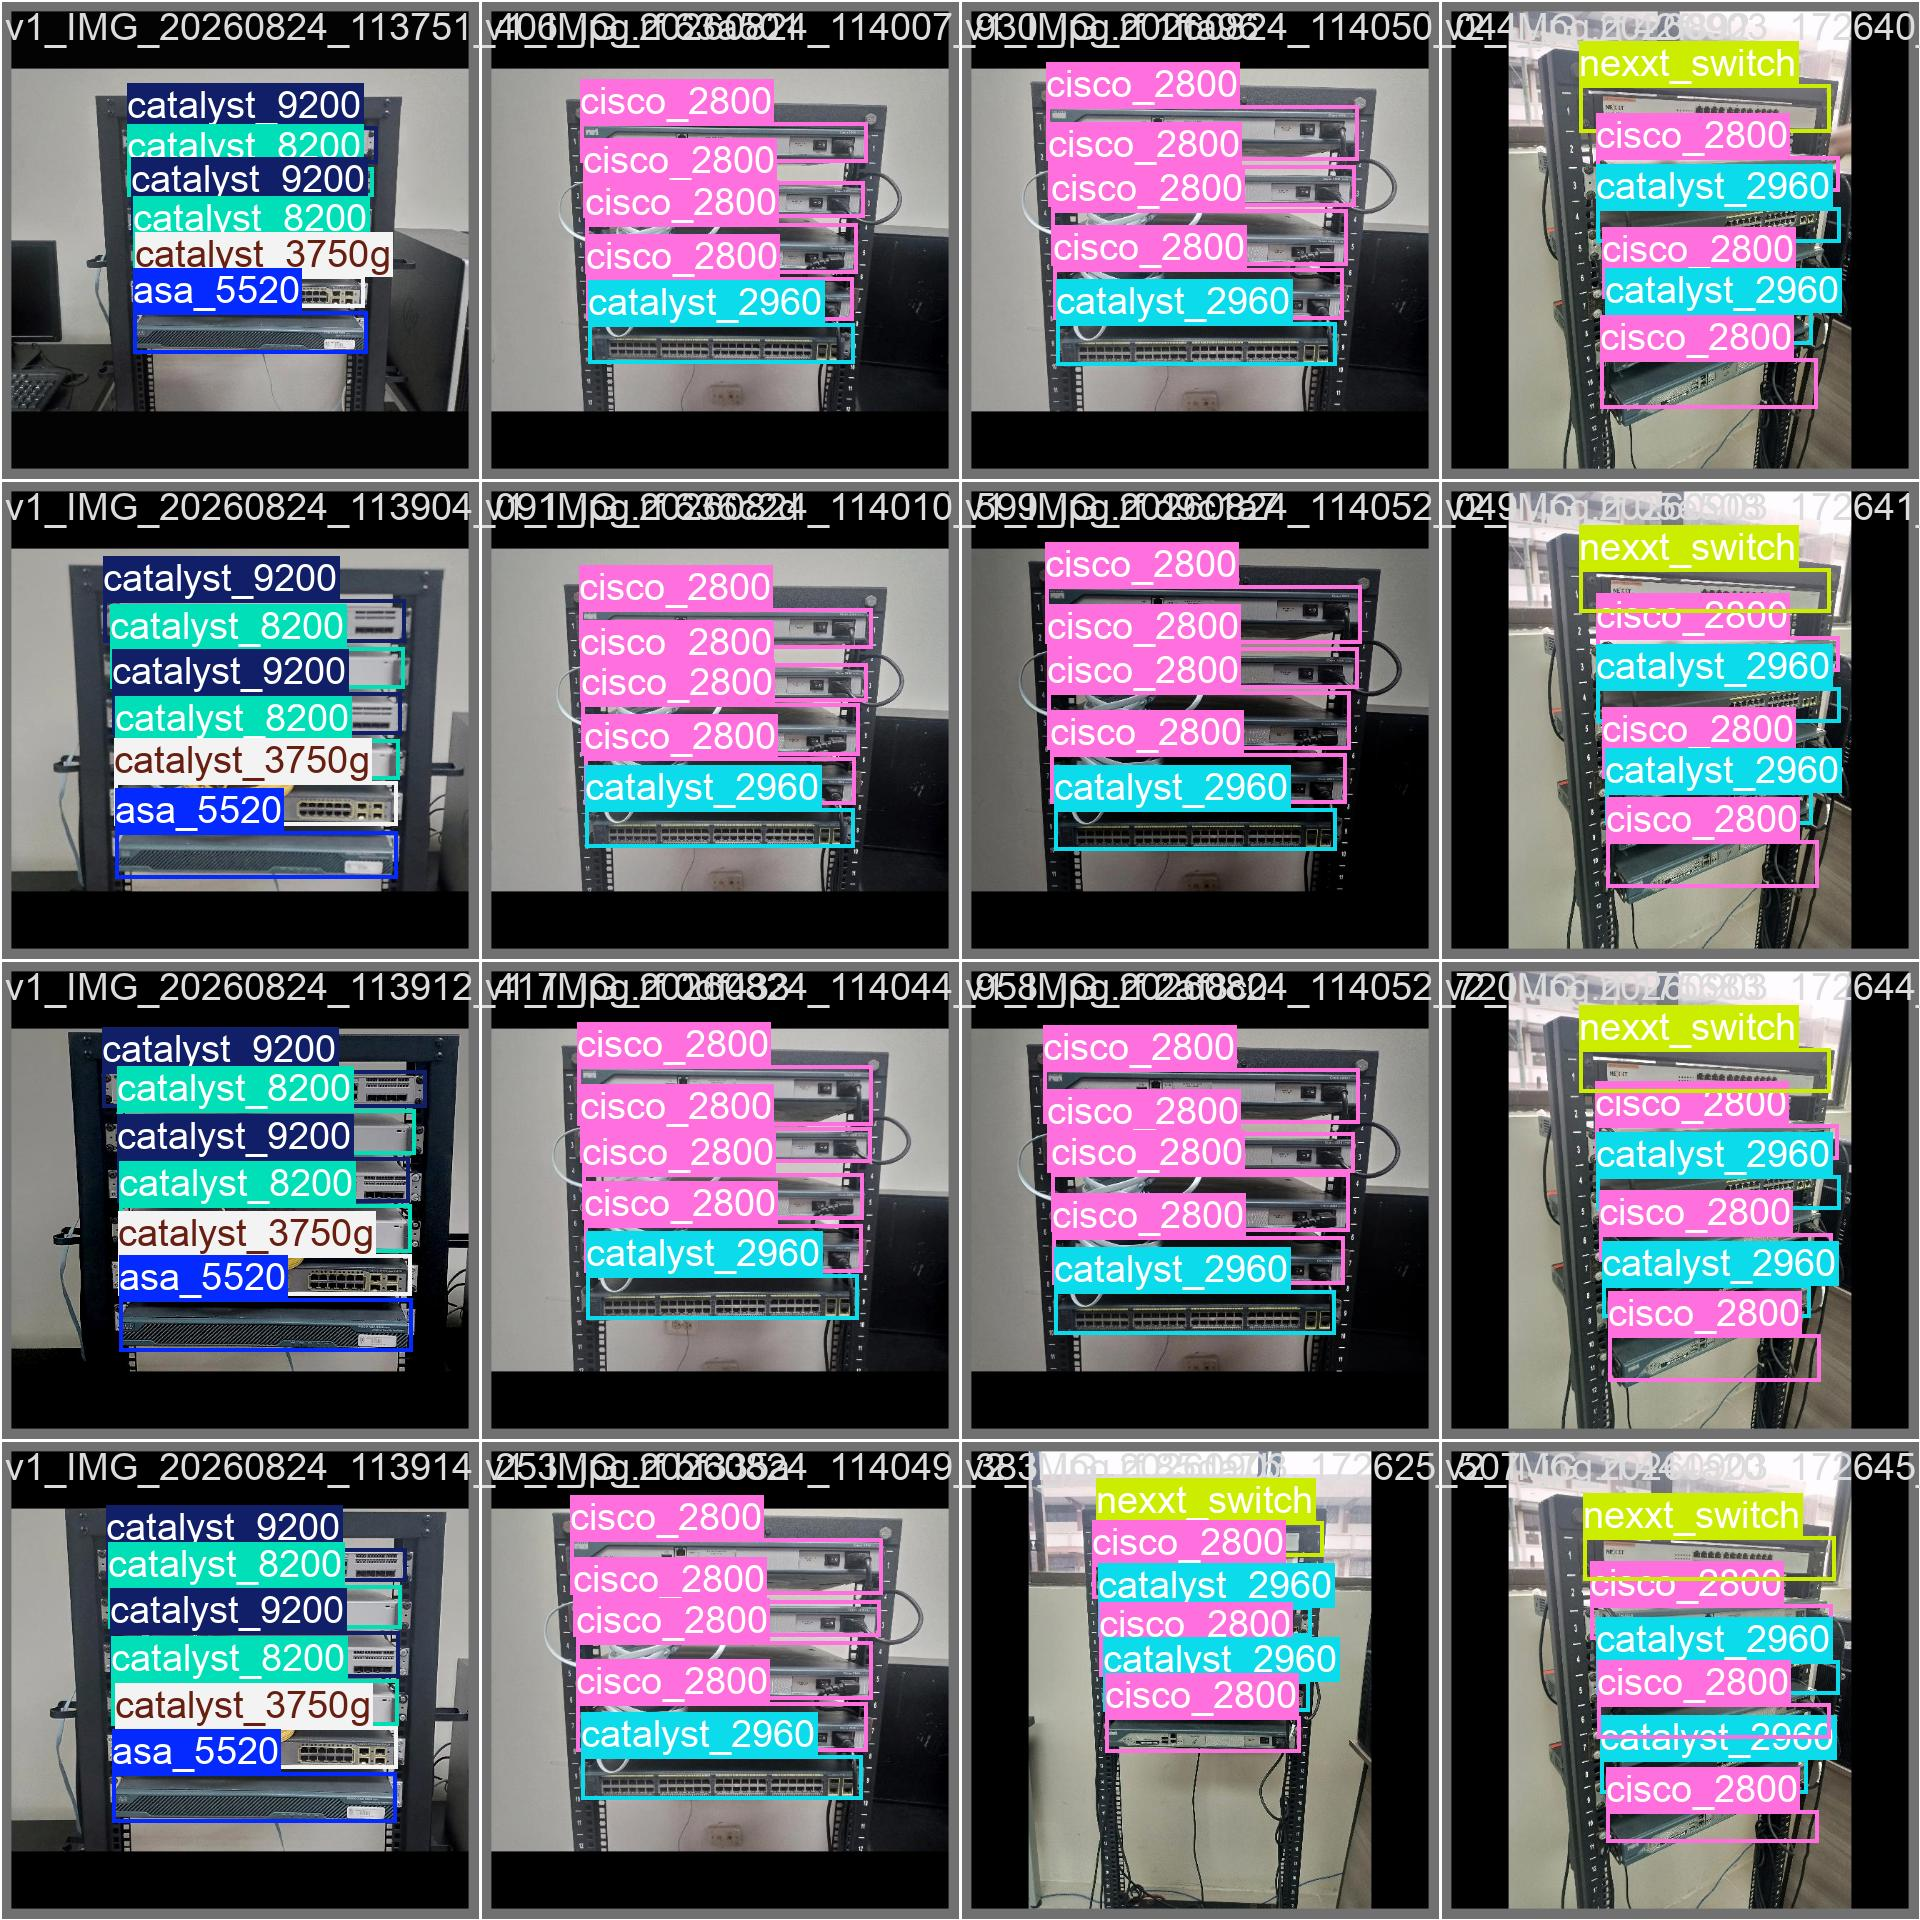


=== Predicciones del modelo ===


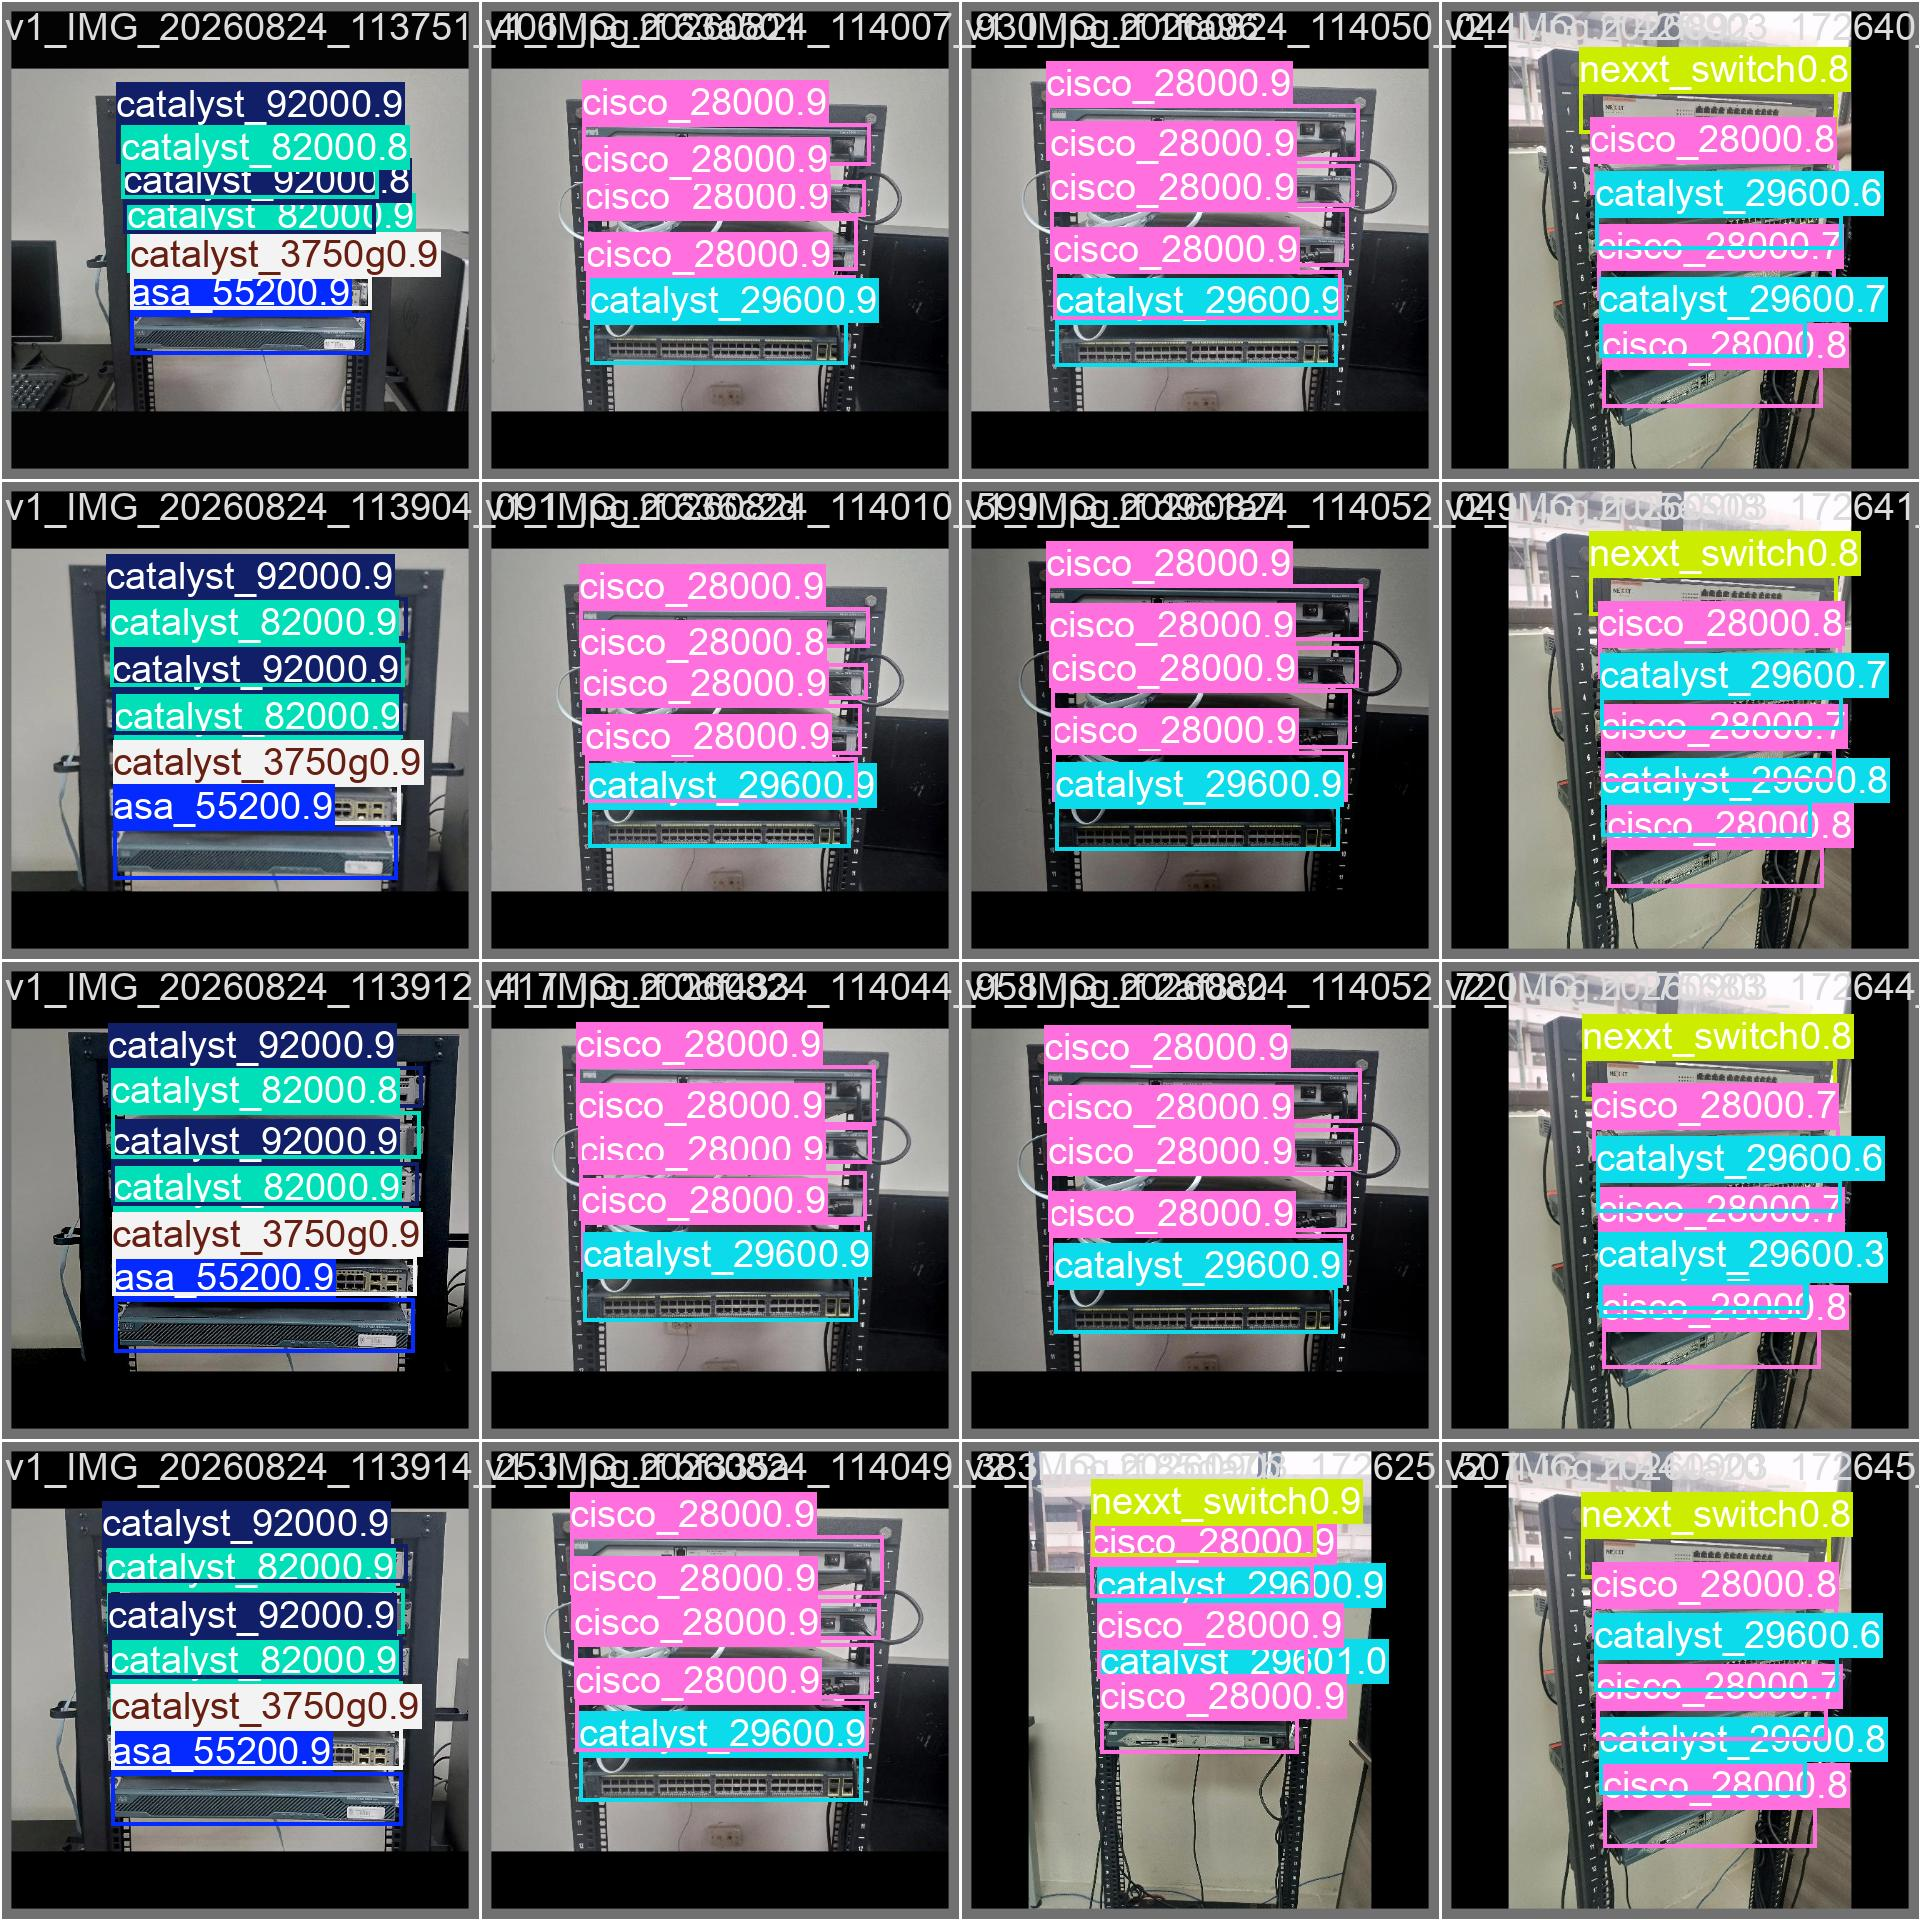

In [ ]:
from IPython.display import Image, display

for archivo, titulo in [
    (f"{R}/labels.jpg",                      "Distribucion de clases y cajas"),
    (f"{R}/results.png",                     "Curvas de entrenamiento"),
    (f"{R}/confusion_matrix_normalized.png", "Matriz de confusion"),
    (f"{R}/val_batch0_labels.jpg",           "Ground truth (lo que etiquetaste)"),
    (f"{R}/val_batch0_pred.jpg",             "Predicciones del modelo"),
]:
    if os.path.exists(archivo):
        print(f"\n=== {titulo} ===")
        display(Image(filename=archivo, width=900))

**Cómo leer la matriz de confusión**: la diagonal son los aciertos. La columna `background` son falsos positivos (detectó algo donde no había nada etiquetado); la fila `background` son objetos que se le escaparon. En el v0 aparecía un falso positivo de `catalyst_8300` contra fondo — si vuelve a salir, menciónalo tú antes de que lo pregunten: es análisis, no un error que ocultar.

---
## 6 · Detección en vivo sobre fotos nuevas

**Esto es lo que más impresiona en un avance.** Sube dos o tres fotos que no estén en el dataset — idealmente tomadas con el celular ahora mismo, en otro ángulo o con otra luz. Es la prueba de que el modelo generaliza, no de que memorizó.

Saving IMG_4416.HEIC to IMG_4416 (2).HEIC
Saving IMG_4005.HEIC to IMG_4005 (2).HEIC

image 1/1 /content/IMG_4416 (2).jpg: 768x1024 2 catalyst_3750gs, 52.8ms
Speed: 5.1ms preprocess, 52.8ms inference, 1.4ms postprocess per image at shape (1, 3, 768, 1024)

=== IMG_4416 (2).jpg ===
   catalyst_3750g          37.8%
   catalyst_3750g          27.1%


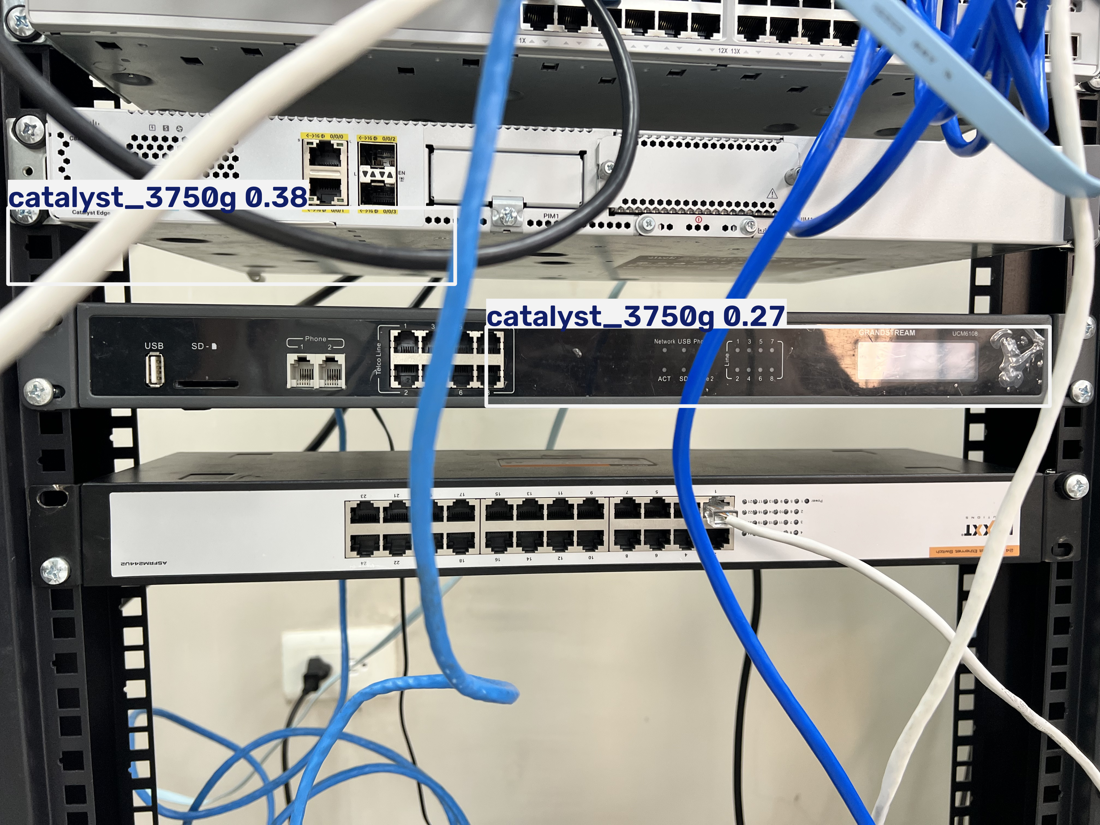


image 1/1 /content/IMG_4005 (2).jpg: 1024x768 2 catalyst_2960s, 4 cisco_2800s, 1 nexxt_switch, 52.3ms
Speed: 4.8ms preprocess, 52.3ms inference, 1.6ms postprocess per image at shape (1, 3, 1024, 768)

=== IMG_4005 (2).jpg ===
   cisco_2800              89.2%
   catalyst_2960           89.0%
   cisco_2800              86.6%
   catalyst_2960           86.1%
   cisco_2800              81.0%
   nexxt_switch            79.5%
   cisco_2800              40.5%


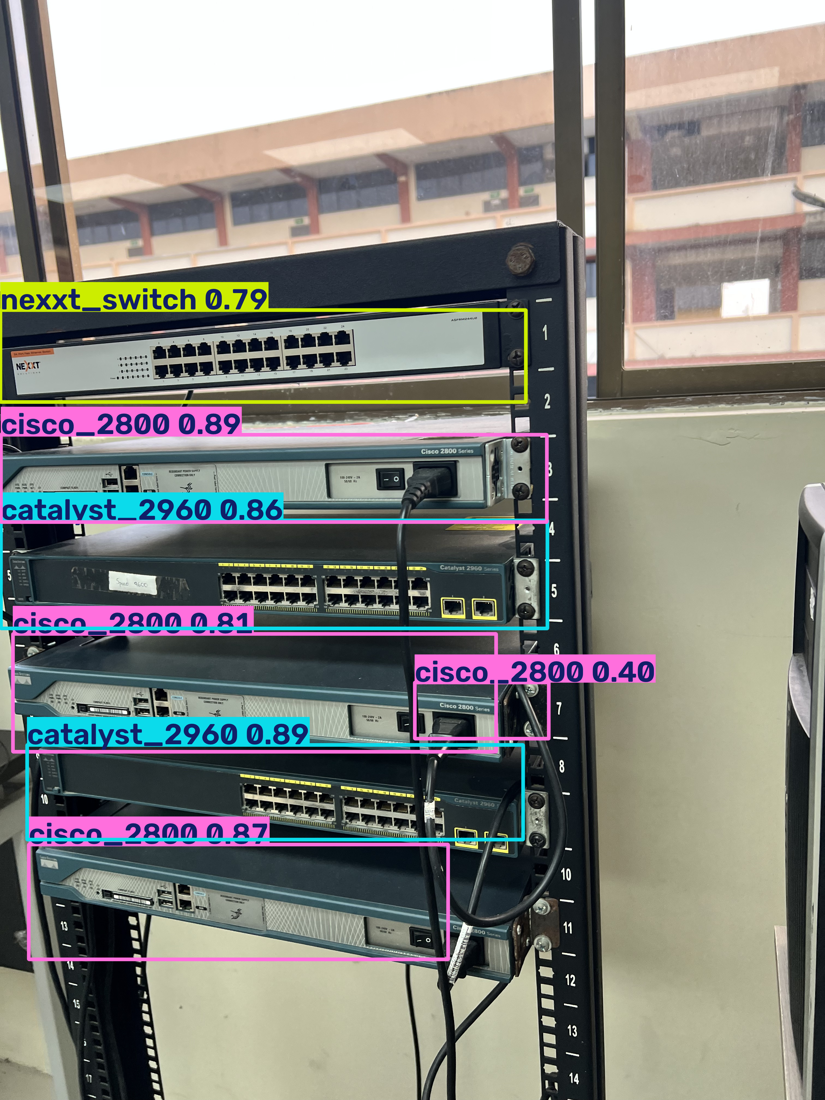

In [ ]:
!pip -q install pillow-heif

import pillow_heif
from PIL import Image as PILImage
from pathlib import Path
from google.colab import files
from IPython.display import display

pillow_heif.register_heif_opener()

subidas = files.upload()

for nombre in subidas:
    ruta = Path(nombre)
    if ruta.suffix.lower() in {".heic", ".heif"}:
        im = PILImage.open(ruta).convert("RGB")
        ruta = ruta.with_suffix(".jpg")
        im.save(ruta, quality=95)

    r = best.predict(str(ruta), conf=0.25, iou=0.45, imgsz=1024)[0]

    print(f"\n=== {ruta.name} ===")
    if len(r.boxes) == 0:
        print("   (sin detecciones)")
    for b in sorted(r.boxes, key=lambda x: -float(x.conf)):
        print(f"   {FINAL[int(b.cls)]:<22} {float(b.conf)*100:>5.1f}%")

    anotada = PILImage.fromarray(r.plot()[:, :, ::-1])   # BGR -> RGB
    anotada.thumbnail((1100, 1100))
    display(anotada)
    anotada.save(f"demo_{ruta.stem.split()[0]}.jpg")     # para descargar después

---
## 7 · Exportar a TFLite

Este archivo es el que después va dentro de la app Android, en `assets/`. Aunque el modelo siga siendo un avance, tenerlo exportado demuestra que el pipeline completo funciona de punta a punta.

In [ ]:
ruta = str(best.export(format="tflite", imgsz=640))
if not ruta.endswith(".tflite"):
    ruta = sorted(glob.glob(f"{ruta}/*float32.tflite"))[0]

shutil.copy(ruta, "modelo_redes_uteq.tflite")
shutil.copy(f"{R}/weights/best.pt", "modelo_redes_uteq.pt")

# labels.txt en el MISMO orden que data.yaml: la app mapea por indice
with open("labels.txt", "w") as f:
    f.write("\n".join(FINAL))

print(f"tflite: {os.path.getsize('modelo_redes_uteq.tflite')/1e6:.1f} MB")
print("\nlabels.txt:")
print("\n".join(f"  {i}  {n}" for i, n in enumerate(FINAL)))

WARNING ⚠️ format='tflite' is deprecated as of 8.4.83 and has been replaced by the unified Google LiteRT format. Exporting format='litert' instead. See https://docs.ultralytics.com/integrations/litert
Ultralytics 8.4.144 🚀 Python-3.13.15 torch-2.11.0+cu128 CPU (Intel Xeon CPU @ 2.00GHz)
💡 ProTip: Export to OpenVINO format for best performance on Intel hardware. Learn more at https://docs.ultralytics.com/integrations/openvino
YOLO11n summary (fused): 100 layers, 2,583,907 parameters, 0 gradients, 6.4 GFLOPs

PyTorch: starting from 'runs/detect/redes_uteq_v1_n/weights/best.pt' with input shape (1, 3, 640, 640) BCHW and output shape(s) (1, 13, 8400) (5.2 MB)
requirements: Ultralytics requirements ['litert-torch>=0.9.0', 'ai-edge-litert>=2.1.4'] not found, attempting AutoUpdate...
Using Python 3.13.15 environment at: /usr
Resolved 86 packages in 631ms
Prepared 15 packages in 6.42s
Uninstalled 3 packages in 59ms
Installed 15 packages in 38ms
 + ai-edge-litert==2.2.0
 + ai-edge-quantizer==0.

invalid escape sequence '\.'



LiteRT: starting export with litert_torch 0.9.4...


(00:00) [START] LiteRT-Torch Convert

(00:00) [START] LiteRT-Torch Convert > Torch Export: serving_default

...

(00:15) [ DONE] LiteRT-Torch Convert > Run LiteRT Converter Passes (+00:00)

(00:15) [ DONE] LiteRT-Torch Convert (+00:15)

(00:00) [START] Write Model to runs/detect/redes_uteq_v1_n/weights/best.tflite

(00:00) [ DONE] Write Model to runs/detect/redes_uteq_v1_n/weights/best.tflite (+00:00)

LiteRT: export success ✅ 26.7s, saved as 'runs/detect/redes_uteq_v1_n/weights/best.tflite' (10.1 MB)

Export complete (27.2s)
Results saved to /content/runs/detect/redes_uteq_v1_n/weights/best.tflite
Predict:         yolo predict task=detect model=runs/detect/redes_uteq_v1_n/weights/best.tflite imgsz=640 
Validate:        yolo val task=detect model=runs/detect/redes_uteq_v1_n/weights/best.tflite imgsz=640 data=/content/merged/data.yaml  
Visualize:       https://netron.app
tflite: 10.6 MB

labels.txt:
  0  asa_5520
  1  catalyst_2960
  2  catalyst_3750g
  3  catalyst_8200
  4  catalyst_9200
  5  cisco_2800
  6  grandstream_ucm
  7  nexxt_switch
  8  telefono_yealink


---
## 8 · Descargar todo

In [ ]:
!zip -qr resultados_v1.zip runs demo_*.jpg labels.txt modelo_redes_uteq.tflite modelo_redes_uteq.pt
from google.colab import files
files.download("resultados_v1.zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

---
## Cómo interpretar tu resultado

| mAP50 | Qué significa | Qué decir |
|---|---|---|
| **> 0.70** | El modelo detecta bien | "Con N imágenes alcanzamos 0.7X; con el dataset completo esperamos superar 0.85" |
| **0.45 – 0.70** | Detecta, con confusiones entre modelos parecidos | "Las clases X e Y se confunden; el plan es reforzarlas con tomas de la etiqueta de marca" |
| **< 0.45** | Faltan datos, esperable a esta escala | "El pipeline está validado de punta a punta; el cuello de botella es volumen de datos, no arquitectura" |

Los tres son avances presentables. Lo que no funciona es dar un número de precisión sin decir sobre cuántas imágenes se entrenó: con contexto un mAP bajo es honesto, sin él parece un fracaso.

### Dos cosas que conviene que digas tú primero

**El desbalance de clases.** Si una clase concentra buena parte de las cajas, su mAP alto arrastra el promedio hacia arriba. Muestra la tabla por clase, no solo el número global.

**Las ráfagas de fotos.** Buena parte de las tomas nuevas se dispararon a menos de un segundo de distancia entre sí, así que muchas son casi la misma imagen. Cuentan como imágenes distintas pero aportan mucha menos variedad de la que sugiere el número. Vale más decirlo como hallazgo —"la próxima tanda hay que tomarla variando ángulo, distancia e iluminación"— que dejar que lo note alguien más.

### Frase para arrancar

> "Este es el modelo v1, entrenado sobre el dataset fusionado de las dos tandas de captura. Ya valida el flujo completo Roboflow → YOLO → TFLite. La siguiente etapa es completar el dataset y montarlo en la aplicación Android."


In [ ]:
!zip -qr dataset_merged_v1.zip /content/merged
from google.colab import files
files.download("dataset_merged_v1.zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>